In [36]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [17]:
califonia_housing = fetch_california_housing() 
califonia_housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [18]:
califonia_housing_dataset = pd.DataFrame(califonia_housing['data'], columns = califonia_housing['feature_names'])
califonia_housing_dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [19]:
califonia_housing_dataset['MedHouseVal'] = califonia_housing['target']
califonia_housing_dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [21]:
X = califonia_housing_dataset.drop('MedHouseVal', axis=1)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [27]:
Y = califonia_housing_dataset['MedHouseVal']
Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=123, shuffle=True)

In [30]:
linearRegression = LinearRegression()
ridge = Ridge()
lasso = Lasso()
elasticNet = ElasticNet()

In [33]:
linearRegression.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elasticNet.fit(X_train, y_train)

ElasticNet()

In [39]:
models = {
    "Linear": linearRegression,
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elasticNet
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name)
    mse = mean_squared_error(y_pred, y_test)
    print("mse: ", mse)
    r2 = r2_score(y_pred, y_test)
    print("r2 score: ", r2)
    print()



Linear
mse:  0.5180228655178677
r2 score:  0.3659260090783124

Ridge
mse:  0.5180225821074518
r2 score:  0.36582433271878845

Lasso
mse:  0.9498238036552328
r2 score:  -11.238907376554574

ElasticNet
mse:  0.765016098984279
r2 score:  -2.2416394937303337



In [35]:
import matplotlib.pyplot as plt

      Feature  Coefficient
7   Longitude    -0.427677
6    Latitude    -0.417034
2    AveRooms    -0.111828
5    AveOccup    -0.003923
4  Population    -0.000007
1    HouseAge     0.009158
0      MedInc     0.439988
3   AveBedrms     0.647858


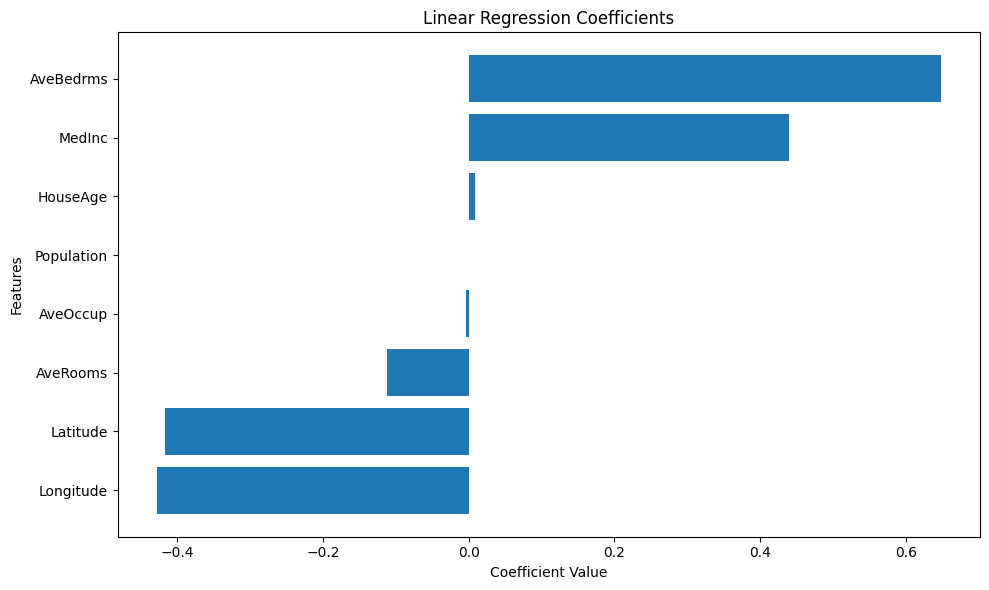

      Feature  Coefficient
7   Longitude    -0.427645
6    Latitude    -0.417019
2    AveRooms    -0.111587
5    AveOccup    -0.003923
4  Population    -0.000007
1    HouseAge     0.009160
0      MedInc     0.439862
3   AveBedrms     0.646611


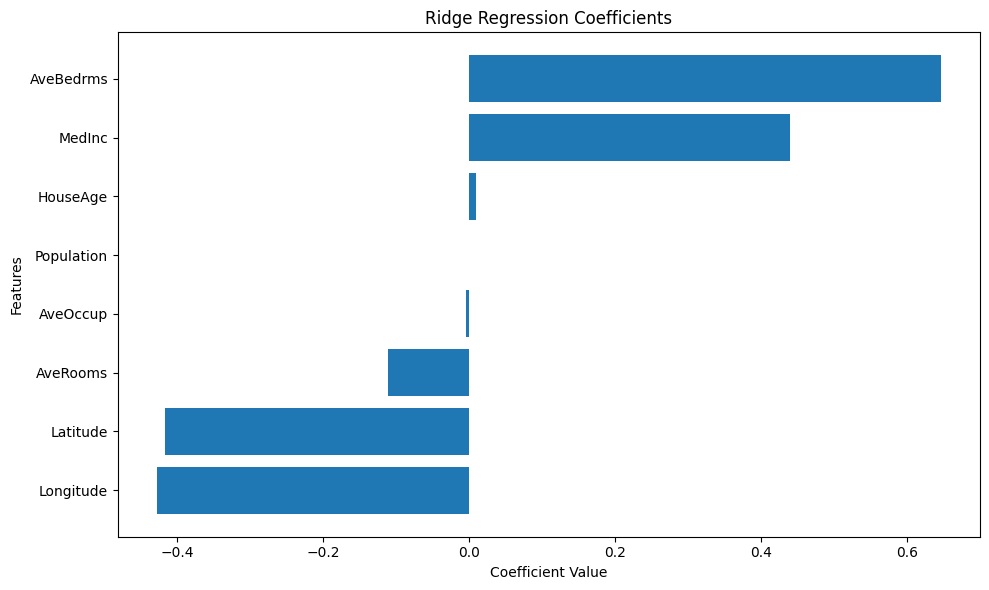

      Feature  Coefficient
4  Population    -0.000008
2    AveRooms     0.000000
3   AveBedrms    -0.000000
5    AveOccup    -0.000000
6    Latitude    -0.000000
7   Longitude    -0.000000
1    HouseAge     0.005284
0      MedInc     0.145779


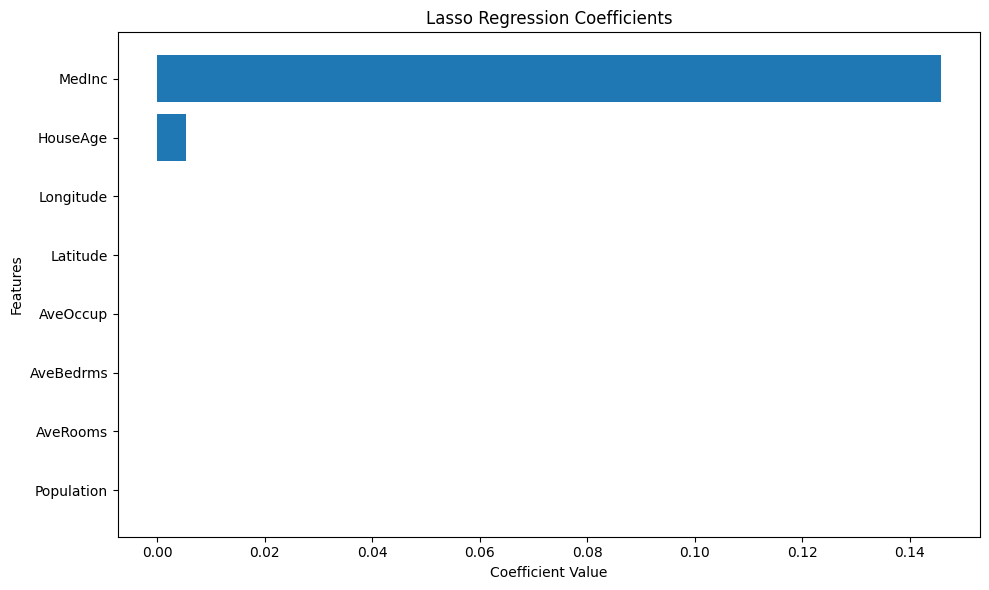

      Feature  Coefficient
2    AveRooms     0.000000
3   AveBedrms    -0.000000
5    AveOccup    -0.000000
6    Latitude    -0.000000
7   Longitude    -0.000000
4  Population     0.000008
1    HouseAge     0.010844
0      MedInc     0.253590


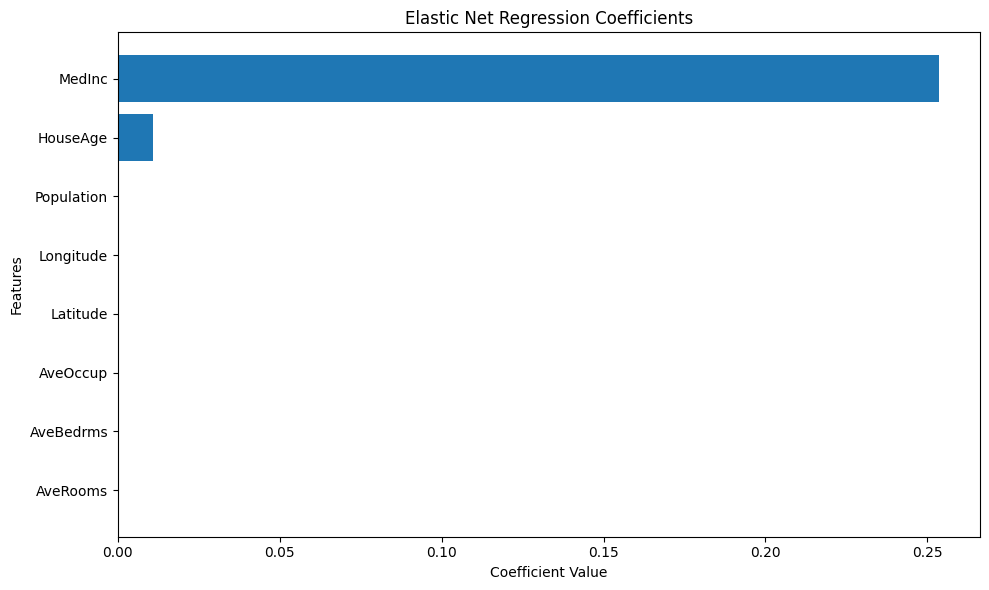

In [46]:
import matplotlib.pyplot as plt

# Function to plot coefficients
def plot_coefficients(model, feature_names, title):
    
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    coef_df = coef_df.sort_values(by="Coefficient")
    print(coef_df)
        
    plt.figure(figsize=(10,6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    
    plt.title(title)
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    
    plt.tight_layout()
    plt.show()


# Linear Regression
plot_coefficients(
    linearRegression,
    X.columns,
    "Linear Regression Coefficients"
)

# Ridge Regression
plot_coefficients(
    ridge,
    X.columns,
    "Ridge Regression Coefficients"
)

# Lasso Regression
plot_coefficients(
    lasso,
    X.columns,
    "Lasso Regression Coefficients"
)

# Elastic Net
plot_coefficients(
    elasticNet,
    X.columns,
    "Elastic Net Regression Coefficients"
)